# Pochopenie dát 
## 1. Import knižníc

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Načítanie dát

In [5]:
c = ['trustLevel', 'totalScanTimeInSeconds', 'grandTotal', 'lineItemVoids', 'scansWithoutRegistration', 'quantityModifications', 'scannedLineItemsPerSecond', 'valuePerSecond', 'lineItemVoidsPerPosition', 'fraud'] 

train =  pd.read_csv("train.csv", sep='|')#, names=c)
train

,trustLevel,totalScanTimeInSeconds,grandTotal,lineItemVoids,scansWithoutRegistration,quantityModifications,scannedLineItemsPerSecond,valuePerSecond,lineItemVoidsPerPosition,fraud
0,5,1054,54.70,7,0,3,0.027514,0.051898,0.241379,0
1,3,108,27.36,5,2,4,0.129630,0.253333,0.357143,0
2,3,1516,62.16,3,10,5,0.008575,0.041003,0.230769,0
3,6,1791,92.31,8,4,4,0.016192,0.051541,0.275862,0
4,5,430,81.53,3,7,2,0.062791,0.189605,0.111111,0
...,...,...,...,...,...,...,...,...,...,...
1874,1,321,76.03,8,7,2,0.071651,0.236854,0.347826,0
1875,1,397,41.89,5,5,0,0.065491,0.105516,0.192308,1
1876,4,316,41.83,5,8,1,0.094937,0.132373,0.166667,0
1877,2,685,62.68,1,6,2,0.035036,0.091504,0.041667,0


## 3. Zisťovanie kvality dát

In [6]:
train.info()
duplicates = train.duplicated().sum()
print(f"Počet duplicitných riadkov: {duplicates}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1879 entries, 0 to 1878
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   trustLevel                 1879 non-null   int64  
 1   totalScanTimeInSeconds     1879 non-null   int64  
 2   grandTotal                 1879 non-null   float64
 3   lineItemVoids              1879 non-null   int64  
 4   scansWithoutRegistration   1879 non-null   int64  
 5   quantityModifications      1879 non-null   int64  
 6   scannedLineItemsPerSecond  1879 non-null   float64
 7   valuePerSecond             1879 non-null   float64
 8   lineItemVoidsPerPosition   1879 non-null   float64
 9   fraud                      1879 non-null   int64  
dtypes: float64(4), int64(6)
memory usage: 146.9 KB
Počet duplicitných riadkov: 0


## 4. Zisťovanie rozsahov atribútov

In [23]:
#train.describe()
#train.describe().T[['min', 'max']]

for col in c:
    print(f'\n{col}:')
    print(train[col].describe())
    print(f'unique: {len(train[col].unique())}')
    print(f'min: {train[col].min()}')
    print(f'max: {train[col].max()}')
    


trustLevel:
count    1879.000000
mean        3.401809
std         1.709404
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max         6.000000
Name: trustLevel, dtype: float64
unique: 6
min: 1
max: 6

totalScanTimeInSeconds:
count    1879.000000
mean      932.153273
std       530.144640
min         2.000000
25%       474.500000
50%       932.000000
75%      1397.000000
max      1831.000000
Name: totalScanTimeInSeconds, dtype: float64
unique: 1193
min: 2
max: 1831

grandTotal:
count    1879.000000
mean       50.864492
std        28.940202
min         0.010000
25%        25.965000
50%        51.210000
75%        77.285000
max        99.960000
Name: grandTotal, dtype: float64
unique: 1721
min: 0.01
max: 99.96

lineItemVoids:
count    1879.000000
mean        5.469931
std         3.451169
min         0.000000
25%         2.000000
50%         5.000000
75%         8.000000
max        11.000000
Name: lineItemVoids, dtype: float64
unique: 12
min: 0
max: 11


## 5. Vizualizácia početností


trustLevel:


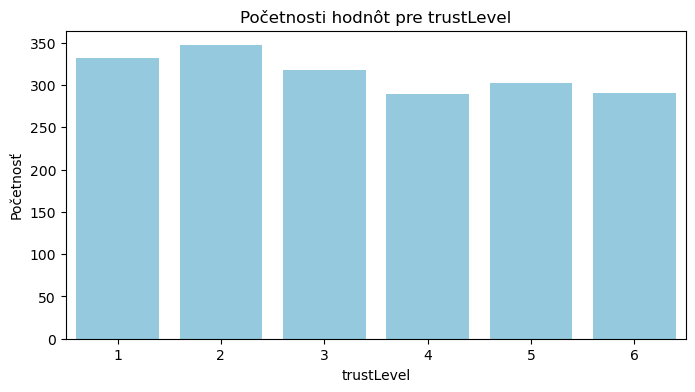


totalScanTimeInSeconds:


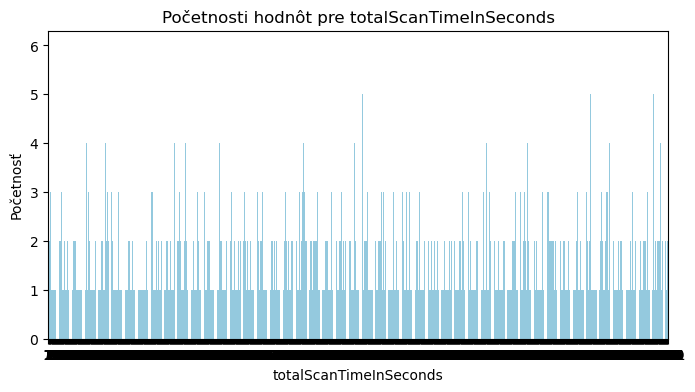


grandTotal:


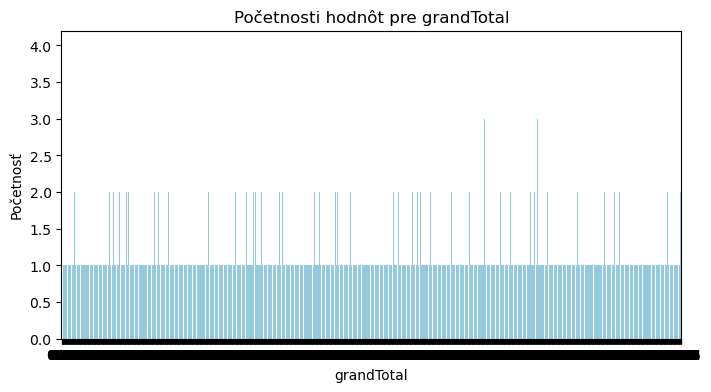


lineItemVoids:


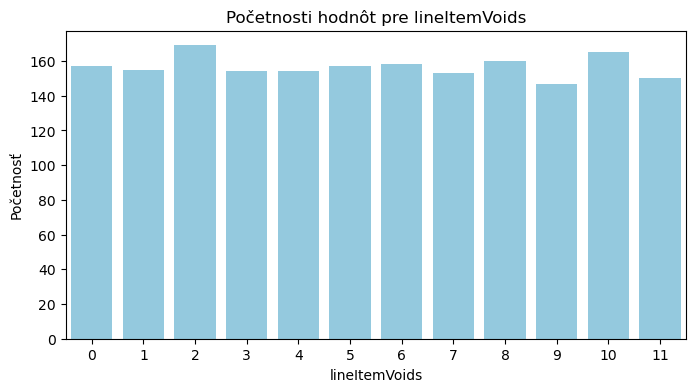


scansWithoutRegistration:


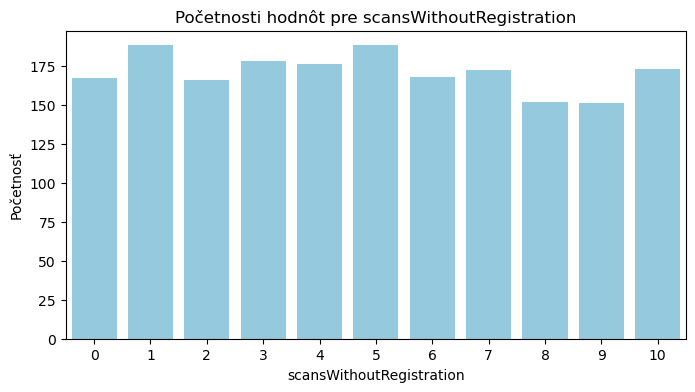


quantityModifications:


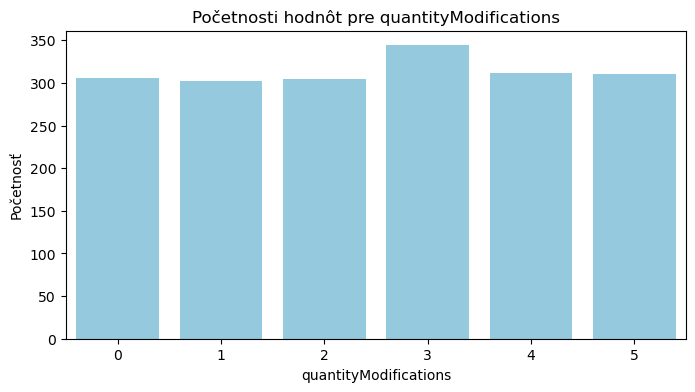


scannedLineItemsPerSecond:


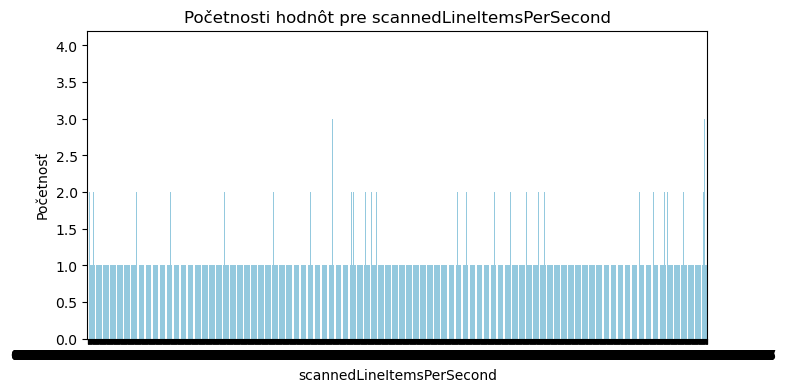


valuePerSecond:


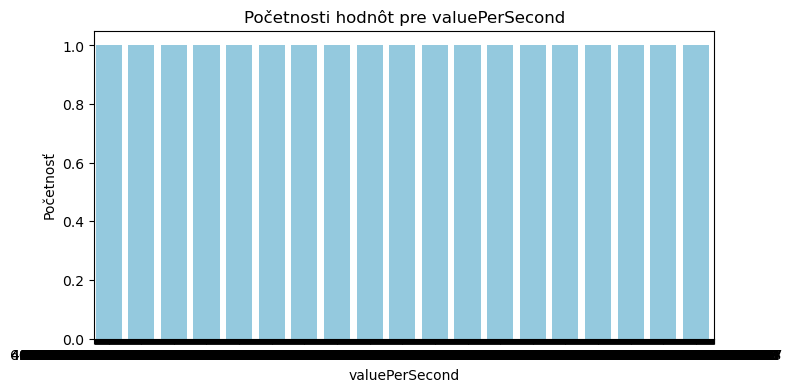


lineItemVoidsPerPosition:


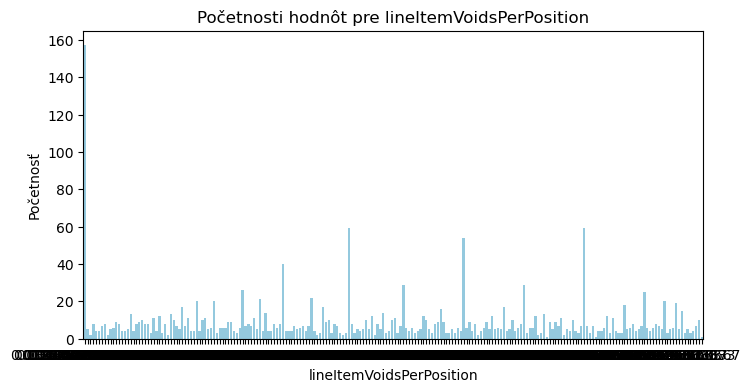


fraud:


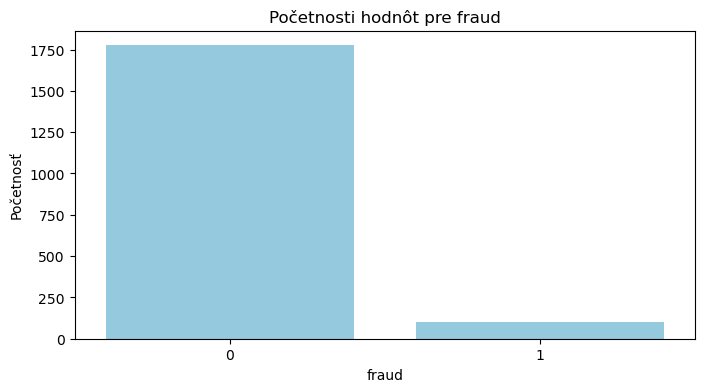

In [8]:
for col in c:
    print(f'\n{col}:')
    
    counts = train[col].value_counts().reset_index()
    counts.columns = [col, 'count']
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=counts[col], y=counts['count'], color = 'skyblue')
    plt.xlabel(col)
    plt.ylabel('Početnosť')
    plt.title(f'Početnosti hodnôt pre {col}')
    plt.show()

## 6. Zistenie outlierov

In [11]:
Q1 = train.quantile(0.25)
#print(Q1)
Q3 = train.quantile(0.75)
#print(Q3)
IQR = Q3 - Q1
#print(IQR)

outliers = ((train < (Q1 - 1.5 * IQR)) | (train > (Q3 + 1.5 * IQR)))

outlier_counts = outliers.sum()

outlier_table = pd.DataFrame({
    'Počet outlierov': outlier_counts,
    'Percento': (outlier_counts / len(train))
})

print(outlier_table)
#outlier_table.to_excel('tabulka_out_train.xlsx')

                           Počet outlierov  Percento
trustLevel                               0  0.000000
totalScanTimeInSeconds                   0  0.000000
grandTotal                               0  0.000000
lineItemVoids                            0  0.000000
scansWithoutRegistration                 0  0.000000
quantityModifications                    0  0.000000
scannedLineItemsPerSecond              222  0.118148
valuePerSecond                         216  0.114955
lineItemVoidsPerPosition               223  0.118680
fraud                                  104  0.055349


## 7. Korelácia pre numerické atribúty

                           totalScanTimeInSeconds  grandTotal  lineItemVoids  scansWithoutRegistration  quantityModifications  scannedLineItemsPerSecond  valuePerSecond  lineItemVoidsPerPosition
totalScanTimeInSeconds                   1.000000   -0.001230       0.019068                  0.009066              -0.011415                  -0.262988       -0.208450                 -0.011623
grandTotal                              -0.001230    1.000000       0.006321                 -0.030573              -0.008163                  -0.011885        0.075679                 -0.008858
lineItemVoids                            0.019068    0.006321       1.000000                 -0.017023              -0.007173                  -0.004438        0.005114                  0.346514
scansWithoutRegistration                 0.009066   -0.030573      -0.017023                  1.000000               0.018961                  -0.024126       -0.018844                  0.002834
quantityModifications    

<Axes: >

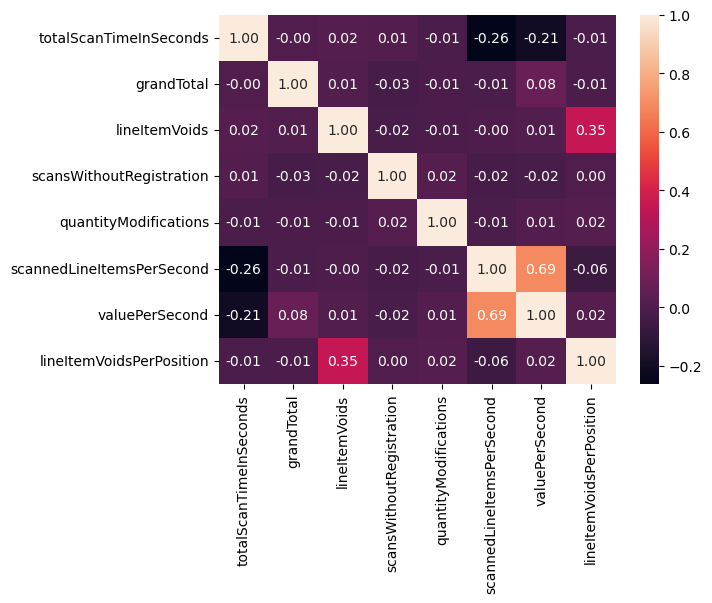

In [14]:
pom_cor = train[['totalScanTimeInSeconds', 'grandTotal', 'lineItemVoids', 'scansWithoutRegistration', 'quantityModifications', 'scannedLineItemsPerSecond', 'valuePerSecond', 'lineItemVoidsPerPosition']]
cr =  pom_cor.corr()
print(cr.to_string())
sns.heatmap(cr, annot=True, fmt='.2f')

## 8. Cieľová trieda

fraud
0    1775
1     104
Name: count, dtype: int64


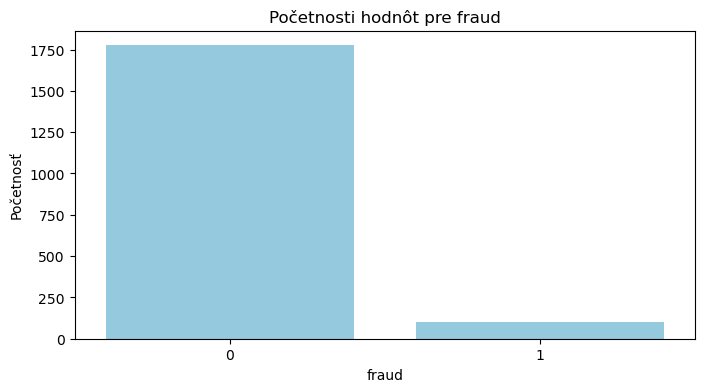

In [15]:
pocetnost = train['fraud'].value_counts()
print(pocetnost)

plt.figure(figsize=(8, 4))
sns.barplot(x=pocetnost.index, y=pocetnost.values, color = 'skyblue')
plt.xlabel('fraud')
plt.ylabel('Početnosť')
plt.title(f'Početnosti hodnôt pre fraud')
plt.show()

## 9. Vzťah cieľovej triedy s numerickými atribútmi 

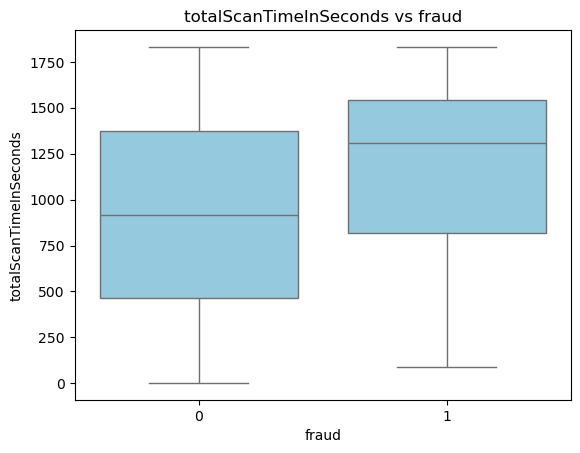

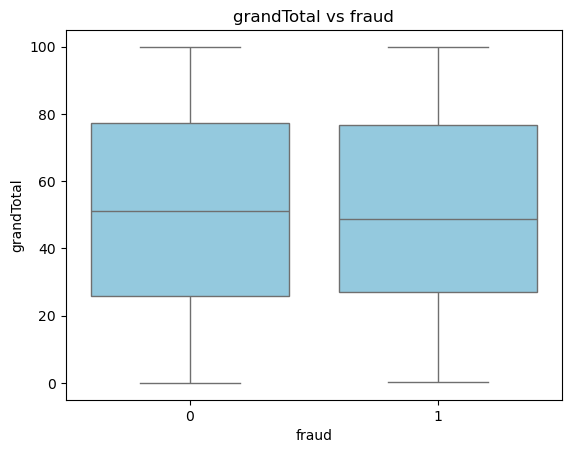

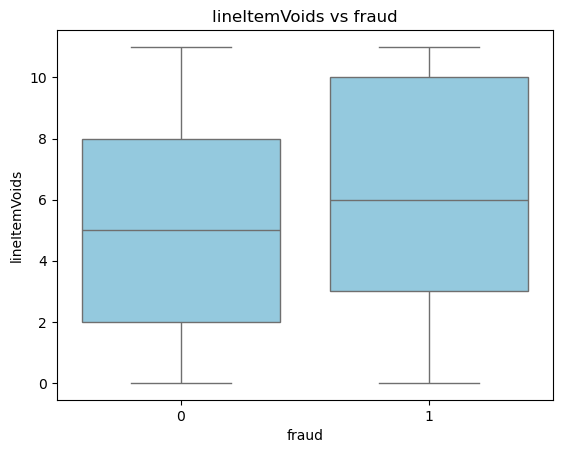

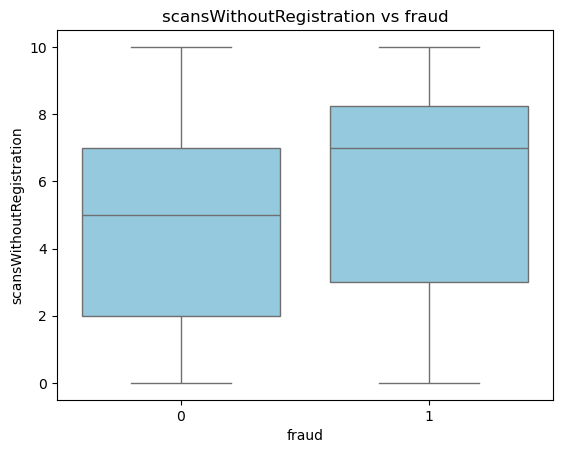

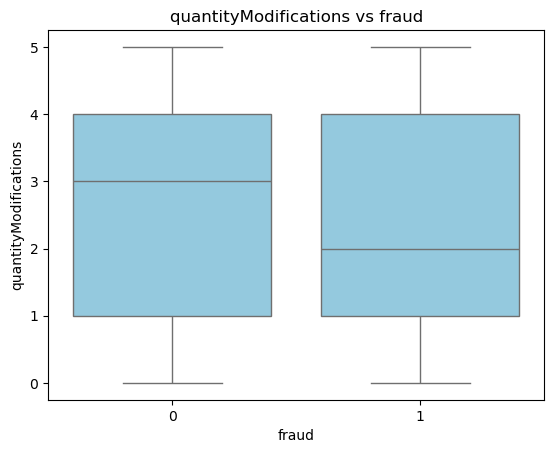

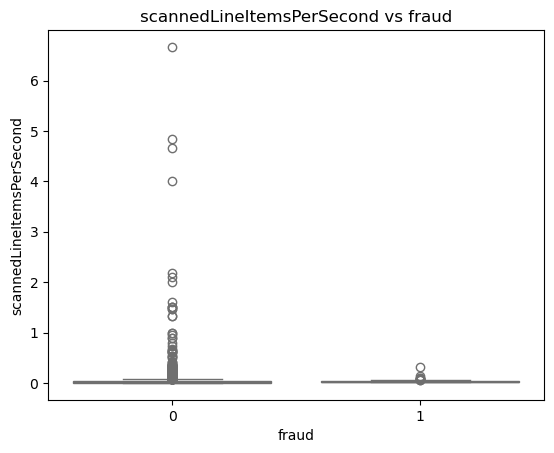

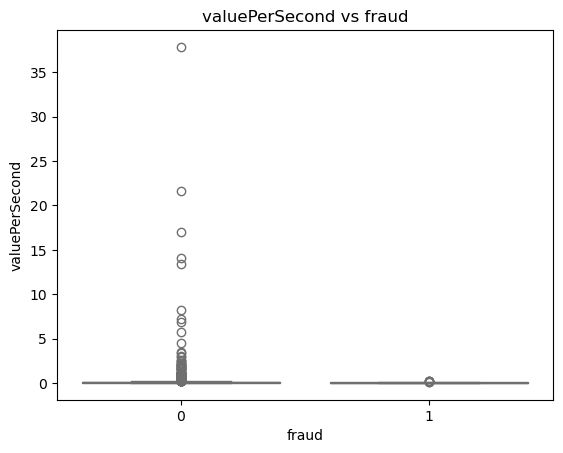

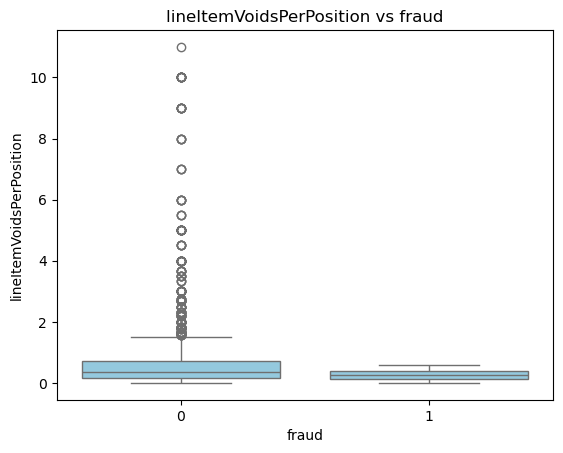

In [20]:
for col in pom_cor:
    #print(f'\n{col}:')
    sns.boxplot(x='fraud', y=col, data=train, color = 'skyblue')
    plt.title(f'{col} vs fraud')
    plt.show()

## 10. Vzťah cieľovej triedy a kategorického atribútu

In [19]:
kont_tab = pd.crosstab(train['trustLevel'], train['fraud'])
kont_tab
#kont_tab.to_excel('tabulka_kont.xlsx')

fraud,0,1
trustLevel,,
1,243,89
2,332,15
3,318,0
4,289,0
5,302,0
6,291,0
